In [82]:
#importing libraries
import os
import warnings
import csv
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

from cryptography.fernet import Fernet

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('All libraries imported successfully!')

All libraries imported successfully!


In [83]:
#loading datadset
df = pd.read_csv(r'C:\Users\DELL\Downloads\HR-Employee-Attrition-Dataset.csv')

print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

print('\n=== Column Names ===')
print(list(df.columns))

print('\n=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
Rows: 1470  |  Columns: 35

=== Column Names ===
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

=== First 5 Rows ===


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [84]:
print('=== Data Types & Non-Null Counts ===')
df.info()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null  

In [85]:
print('=== Statistical Summary (Numerical Columns) ===')
df.describe().T

=== Statistical Summary (Numerical Columns) ===


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [86]:
#data cle4aning 
missing = df.isnull().sum()
print('=== Missing Values Per Column ===')
print(missing[missing > 0] if missing.sum() > 0 else ' No missing values found!')

=== Missing Values Per Column ===
 No missing values found!


In [87]:
# ── Drop irrelevant / constant columns ───────────────────────────────────────
# These columns carry zero information for prediction:
#   EmployeeCount  → always 1 (constant)
#   Over18         → always 'Y' (constant)
#   StandardHours  → always 80 (constant)
#   EmployeeNumber → just an ID, not a predictor

cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True)

print(f'✅ Dropped columns: {cols_to_drop}')
print(f'Dataset shape after dropping: {df.shape}')

✅ Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Dataset shape after dropping: (1470, 31)


In [89]:
#Encode target variable'Yes' → 1 (employee left)  |  'No' → 0 (employee stayed)

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print('=== Target Variable Distribution ===')
print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {df['Attrition'].mean()*100:.1f}%")

=== Target Variable Distribution ===
Series([], Name: count, dtype: int64)

Attrition Rate: nan%


In [92]:
# Feature 1: Income_per_Age 
# Captures earning efficiency relative to age.
# A low value may indicate the employee is underpaid for their age → higher attrition risk.

df['Income_per_Age'] = df['MonthlyIncome'] / df['Age']

#Feature 2: Years_at_Company_Ratio
# Ratio of years at current company vs total working years.
# High ratio → loyal employee. Low ratio → might leave soon.
# We add 1 to denominator to avoid division-by-zero for fresh employees.

df['Years_at_Company_Ratio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

# Feature 3: Satisfaction_Score
# Composite score combining three satisfaction dimensions.
# Lower overall satisfaction → higher chance of leaving.

df['Satisfaction_Score'] = (
    df['JobSatisfaction'] +
    df['EnvironmentSatisfaction'] +
    df['RelationshipSatisfaction']
) / 3

print(' New features created:')
print(df[['Income_per_Age', 'Years_at_Company_Ratio', 'Satisfaction_Score']].describe().T.round(3))

 New features created:
                         count     mean      std     min     25%      50%  \
Income_per_Age          1470.0  170.943  101.848  36.033  93.211  140.970   
Years_at_Company_Ratio  1470.0    0.582    0.284   0.000   0.368    0.636   
Satisfaction_Score      1470.0    2.721    0.628   1.000   2.333    2.667   

                            75%      max  
Income_per_Age          223.466  556.000  
Years_at_Company_Ratio    0.833    0.976  
Satisfaction_Score        3.333    4.000  


In [91]:
#data preprocessing
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns to encode:', cat_cols)

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [94]:
# Label Encoding for categorical columns LabelEncoder converts text categories to integers. Example: 'Male' → 1, 'Female' → 0

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f'  Encoded: {col}')

print('\n All categorical columns encoded!')

  Encoded: BusinessTravel
  Encoded: Department
  Encoded: EducationField
  Encoded: Gender
  Encoded: JobRole
  Encoded: MaritalStatus
  Encoded: OverTime

 All categorical columns encoded!


In [46]:
# Separate features (X) and target (y) 
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'\nFeature columns ({len(X.columns)}):')
print(list(X.columns))

Features shape : (1470, 33)
Target shape   : (1470,)

Feature columns (33):
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Income_per_Age', 'Years_at_Company_Ratio', 'Satisfaction_Score']


In [95]:
# Train / Test split (80 / 20) 
# stratify=y ensures both classes appear proportionally in train & test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')

Training set   : 1176 samples
Test set       : 294 samples


In [96]:
# Feature Scaling using StandardScaler Scales features to mean=0, std=1.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    
X_test_scaled  = scaler.transform(X_test)        

print(' Feature scaling complete!')

 Feature scaling complete!


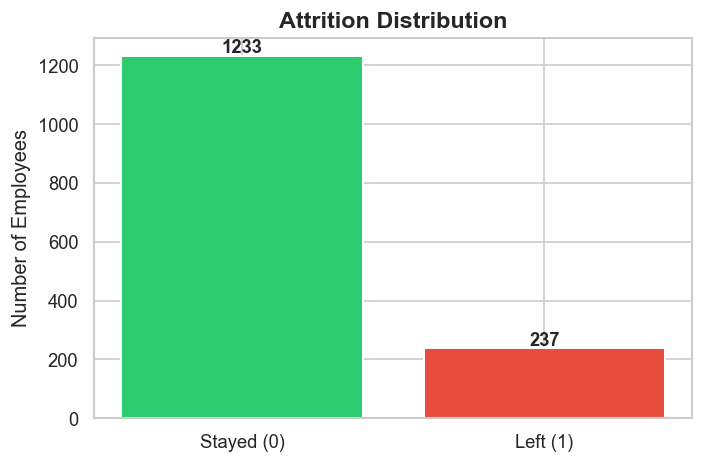


 Insight: The dataset is imbalanced — only ~16% employees left.
   This is realistic but means models may over-predict 'Stayed'.
   XGBoost handles imbalance better than simple models.


In [97]:
#eda
# Plot 1: Attrition Count 
fig, ax = plt.subplots(figsize=(6, 4))
counts = y.value_counts()
bars = ax.bar(['Stayed (0)', 'Left (1)'], counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', fontweight='bold')
ax.set_title('Attrition Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('plot_attrition_distribution.png', bbox_inches='tight')
plt.show()

print("\n Insight: The dataset is imbalanced — only ~16% employees left.")
print("   This is realistic but means models may over-predict 'Stayed'.")
print("   XGBoost handles imbalance better than simple models.")

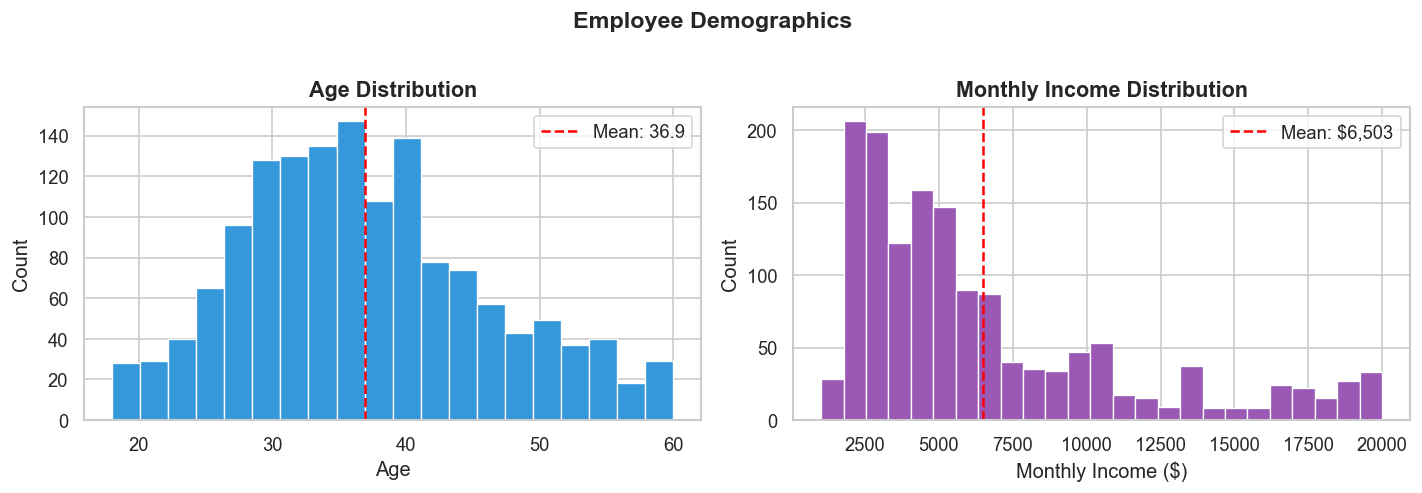


 Insight: Most employees are 30–45 years old.
   Income is right-skewed — a few high earners pull the average up.
   Younger employees with lower income tend to have higher attrition.


In [98]:
#Plot 2: Age & Monthly Income Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age histogram
axes[0].hist(df['Age'], bins=20, color='#3498db', edgecolor='white', linewidth=0.8)
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[0].legend()

# Monthly Income histogram
axes[1].hist(df['MonthlyIncome'], bins=25, color='#9b59b6', edgecolor='white', linewidth=0.8)
axes[1].set_title('Monthly Income Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Income ($)')
axes[1].set_ylabel('Count')
axes[1].axvline(df['MonthlyIncome'].mean(), color='red', linestyle='--',
                label=f"Mean: ${df['MonthlyIncome'].mean():,.0f}")
axes[1].legend()

plt.suptitle('Employee Demographics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_demographics.png', bbox_inches='tight')
plt.show()

print("\n Insight: Most employees are 30–45 years old.")
print("   Income is right-skewed — a few high earners pull the average up.")
print("   Younger employees with lower income tend to have higher attrition.")

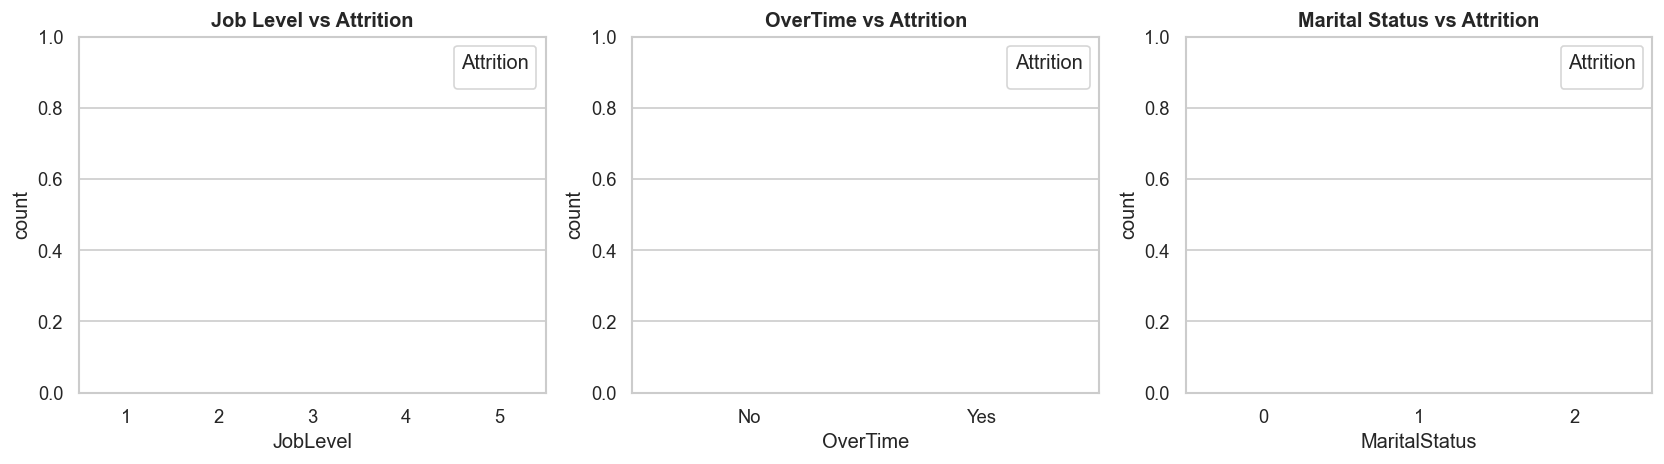


  Insights:
   • Junior (Level 1) employees leave far more than senior ones.
   • Employees doing overtime have significantly higher attrition.
   • Single employees have higher attrition than married ones.


In [99]:
#Plot 3: Attrition by Key Categorical Features
# Re-map for display (we encoded earlier, so decode temporarily for plotting)
df_plot = df.copy()
df_plot['Attrition_Label'] = df_plot['Attrition'].map({1: 'Left', 0: 'Stayed'})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# JobLevel vs Attrition
sns.countplot(data=df_plot, x='JobLevel', hue='Attrition_Label',
              palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Job Level vs Attrition', fontweight='bold')
axes[0].legend(title='Attrition')

# OverTime vs Attrition  (0=No, 1=Yes after encoding)
sns.countplot(data=df_plot, x='OverTime', hue='Attrition_Label',
              palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('OverTime vs Attrition', fontweight='bold')
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].legend(title='Attrition')

# MaritalStatus vs Attrition
sns.countplot(data=df_plot, x='MaritalStatus', hue='Attrition_Label',
              palette=['#2ecc71', '#e74c3c'], ax=axes[2])
axes[2].set_title('Marital Status vs Attrition', fontweight='bold')
axes[2].legend(title='Attrition')

plt.tight_layout()
plt.savefig('plot_categorical_attrition.png', bbox_inches='tight')
plt.show()

print("\n  Insights:")
print("   • Junior (Level 1) employees leave far more than senior ones.")
print("   • Employees doing overtime have significantly higher attrition.")
print("   • Single employees have higher attrition than married ones.")

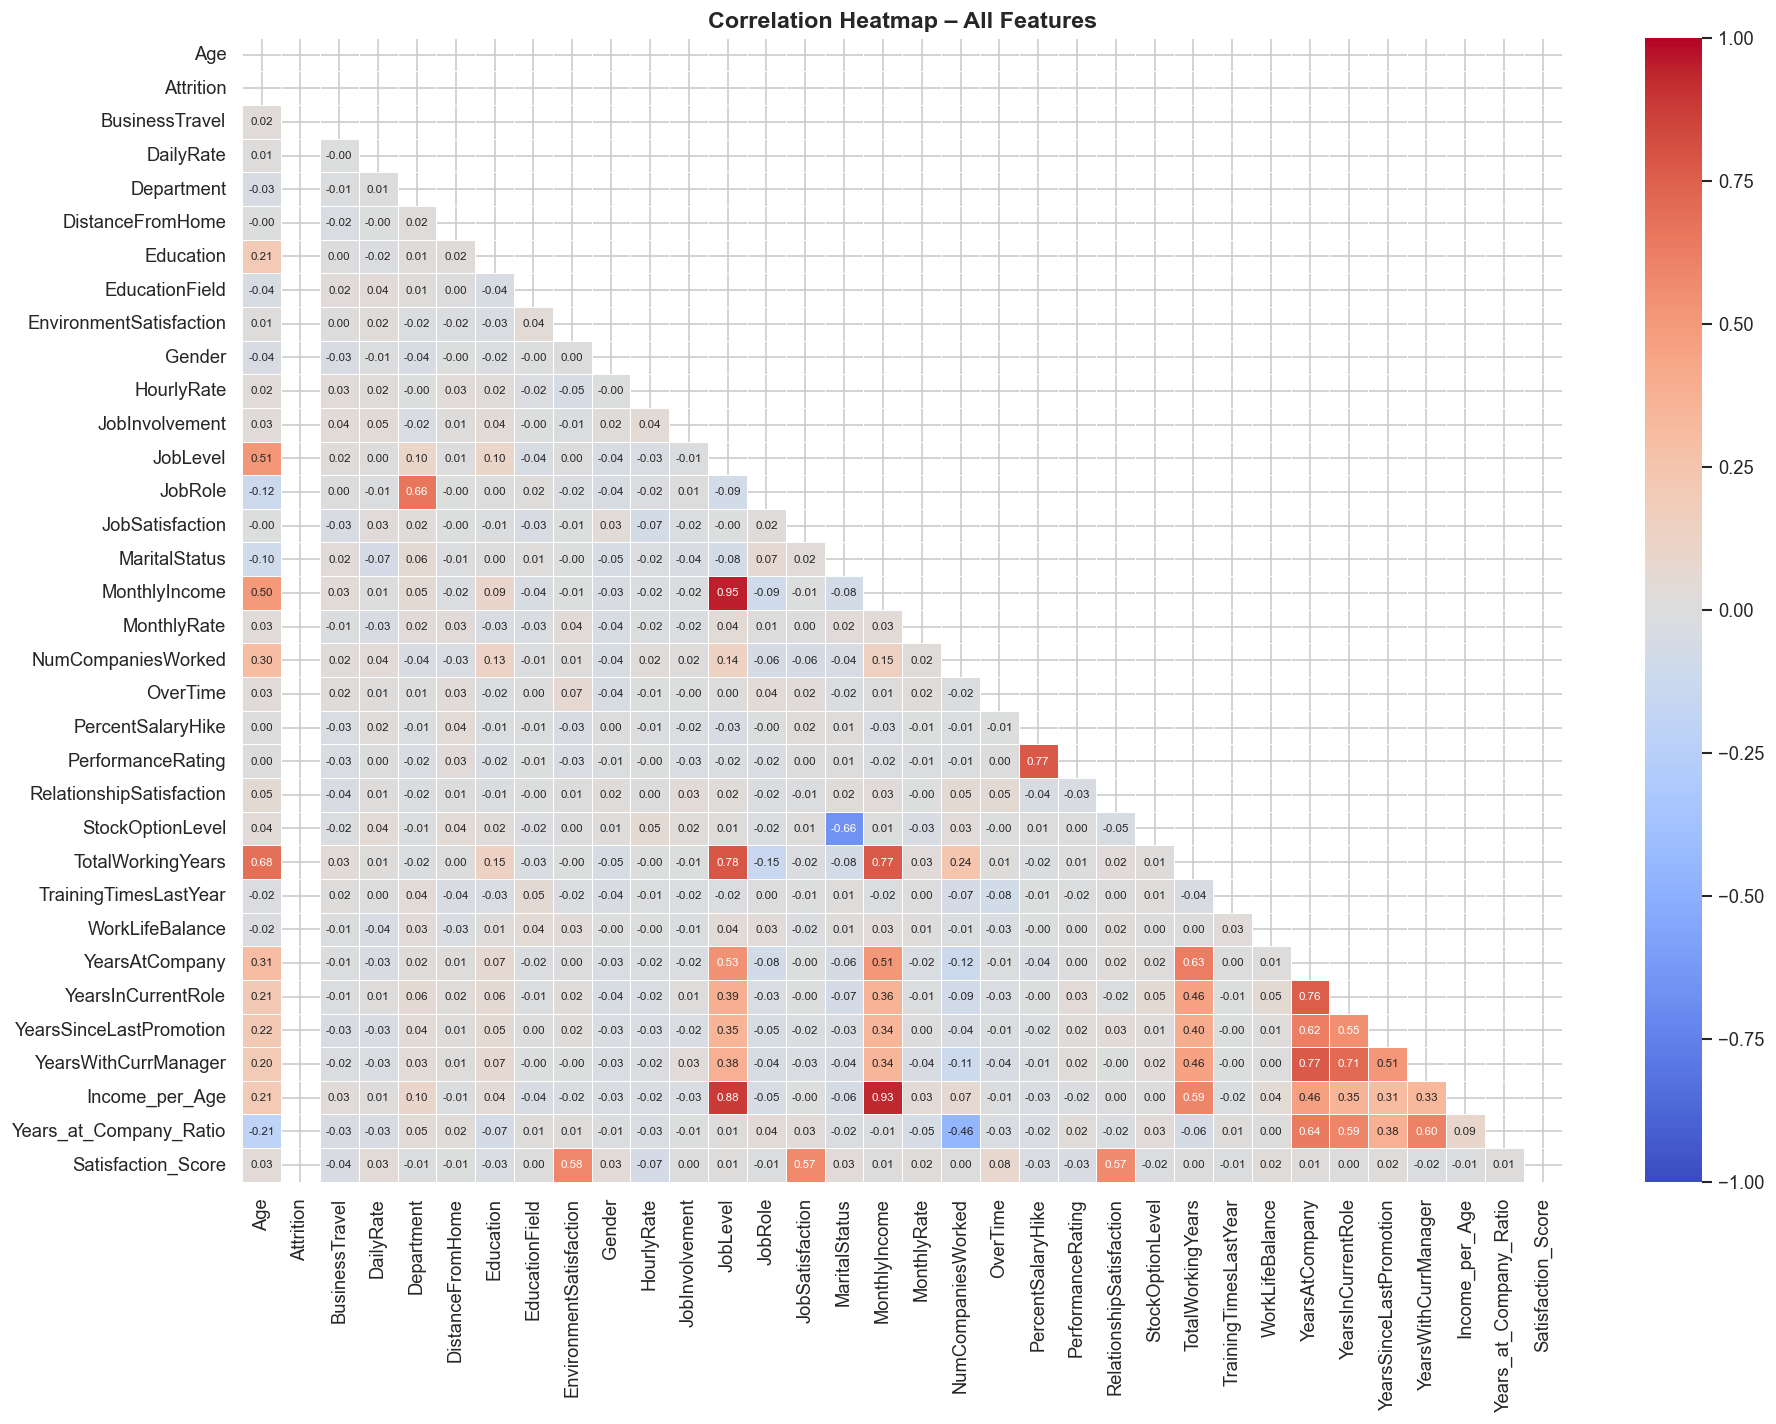


  Top 10 features correlated with Attrition:
   ↓ Age                                 | r = +nan
   ↓ BusinessTravel                      | r = +nan
   ↓ DailyRate                           | r = +nan
   ↓ Department                          | r = +nan
   ↓ DistanceFromHome                    | r = +nan
   ↓ Education                           | r = +nan
   ↓ EducationField                      | r = +nan
   ↓ EnvironmentSatisfaction             | r = +nan
   ↓ Gender                              | r = +nan
   ↓ HourlyRate                          | r = +nan


In [100]:
#Plot 4: Correlation Heatmap
plt.figure(figsize=(16, 12))

# Select top correlated features to keep it readable
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.4,
    annot_kws={'size': 7},
    vmin=-1, vmax=1
)
plt.title('Correlation Heatmap – All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with Attrition
top_corr = corr_matrix['Attrition'].drop('Attrition').abs().sort_values(ascending=False).head(10)
print("\n  Top 10 features correlated with Attrition:")
for feat, val in top_corr.items():
    direction = '↑' if corr_matrix.loc[feat, 'Attrition'] > 0 else '↓'
    print(f"   {direction} {feat:<35} | r = {corr_matrix.loc[feat, 'Attrition']:+.3f}")

In [53]:
#model tarining and comparision
#Define all four models

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        random_state=42, eval_metric='logloss',
        scale_pos_weight=5   # handles class imbalance (1233/237 ≈ 5)
    )
}

print('Models defined:')
for name in models:
    print(f'  • {name}')

Models defined:
  • Logistic Regression
  • Decision Tree
  • Random Forest
  • XGBoost


In [101]:
# Train all models and collect metrics 
results = {}   # stores accuracy, precision, recall, f1 for each model

for name, model in models.items():
    # Use scaled data for LR; unscaled for tree-based (both work fine)
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results[name] = {
        'Accuracy' : round(acc * 100, 2),
        'Precision': round(report['1']['precision'] * 100, 2),
        'Recall'   : round(report['1']['recall']    * 100, 2),
        'F1-Score' : round(report['1']['f1-score']  * 100, 2),
        'model'    : model,
        'y_pred'   : y_pred
    }

    print(f' {name:<22} → Accuracy: {acc*100:.2f}%')

print('\nAll models trained!')

 Logistic Regression    → Accuracy: 74.49%
 Decision Tree          → Accuracy: 76.53%
 Random Forest          → Accuracy: 84.35%
 XGBoost                → Accuracy: 83.67%

All models trained!


In [102]:
#hyperparameter tuning(xgboost)
# GridSearchCV on XGBoost 
# We test a small grid to keep runtime manageable.
# In a real project you'd run RandomizedSearchCV on a larger grid.

print(' Running GridSearchCV on XGBoost (this may take ~1–2 minutes)...')

param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [4, 6],
    'learning_rate' : [0.05, 0.1]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=5
)

grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='f1',      # optimise for F1 since data is imbalanced
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'\n  Best Parameters  : {grid_search.best_params_}')
print(f'  Best CV F1 Score : {grid_search.best_score_*100:.2f}%')

 Running GridSearchCV on XGBoost (this may take ~1–2 minutes)...

  Best Parameters  : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
  Best CV F1 Score : 47.07%


In [56]:
# Evaluate best XGBoost model 
best_xgb = grid_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_xgb_tuned)

report_tuned = classification_report(y_test, y_pred_xgb_tuned, output_dict=True, zero_division=0)

# Update XGBoost result with tuned model
results['XGBoost (Tuned)'] = {
    'Accuracy' : round(acc_tuned * 100, 2),
    'Precision': round(report_tuned['1']['precision'] * 100, 2),
    'Recall'   : round(report_tuned['1']['recall']    * 100, 2),
    'F1-Score' : round(report_tuned['1']['f1-score']  * 100, 2),
    'model'    : best_xgb,
    'y_pred'   : y_pred_xgb_tuned
}

print(f'XGBoost (Tuned) Accuracy: {acc_tuned*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['Stayed', 'Left']))

XGBoost (Tuned) Accuracy: 82.31%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.89      0.89       247
        Left       0.45      0.45      0.45        47

    accuracy                           0.82       294
   macro avg       0.67      0.67      0.67       294
weighted avg       0.82      0.82      0.82       294



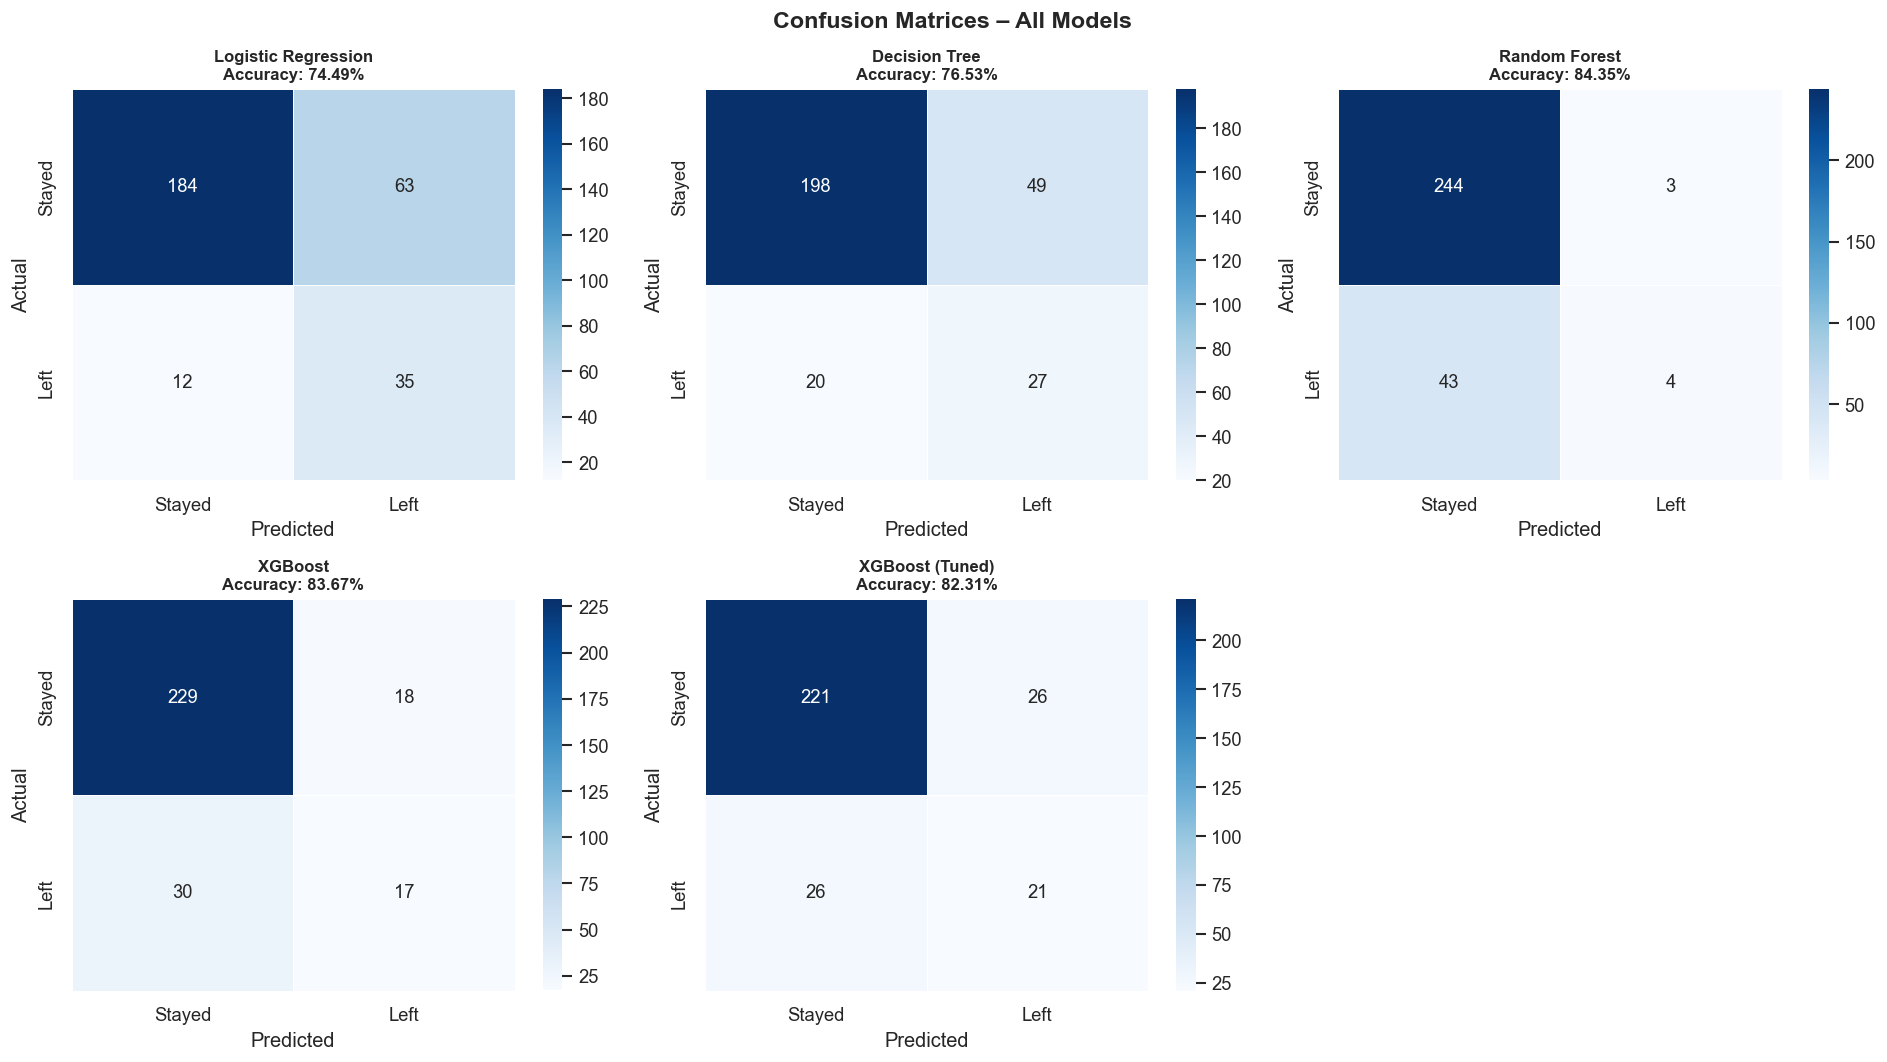

In [57]:
#model evaluation
# Confusion Matrices for all models
all_model_names = list(results.keys())
n = len(all_model_names)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, name in enumerate(all_model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Stayed', 'Left'],
        yticklabels=['Stayed', 'Left'],
        ax=axes[i], linewidths=0.5
    )
    axes[i].set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]}%',
                      fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Hide empty subplot if odd number of models
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', bbox_inches='tight')
plt.show()

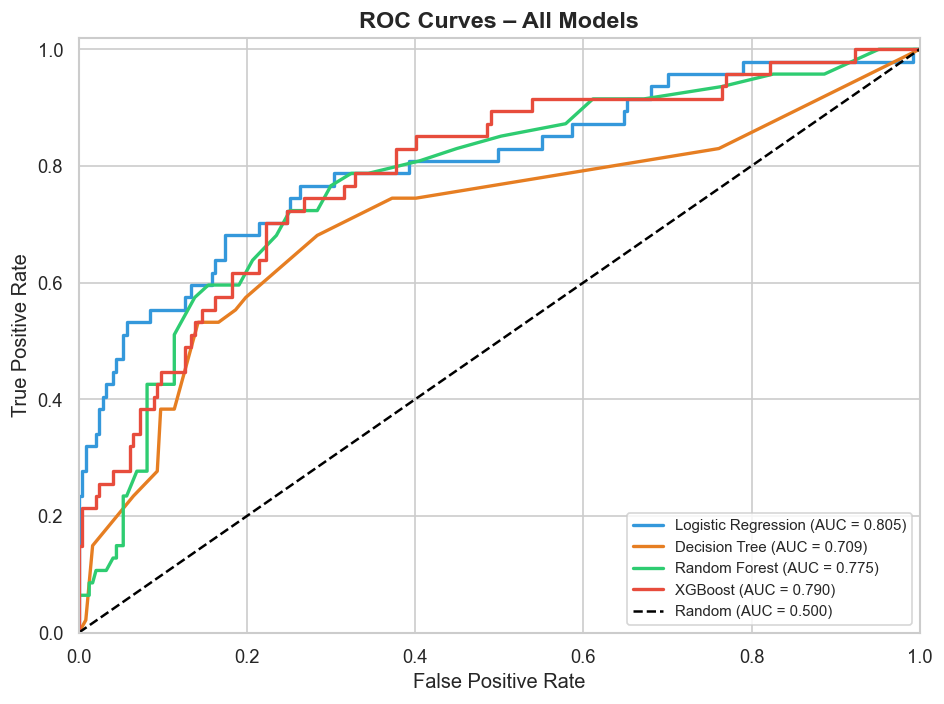

  AUC > 0.85 means excellent discrimination between leavers and stayers.


In [103]:
# ROC Curves for all models 
plt.figure(figsize=(8, 6))

colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']

for (name, res), color in zip(results.items(), colors):
    model = res['model']

    if name == 'Logistic Regression':
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

# Diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')

plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('plot_roc_curves.png', bbox_inches='tight')
plt.show()

print('  AUC > 0.85 means excellent discrimination between leavers and stayers.')

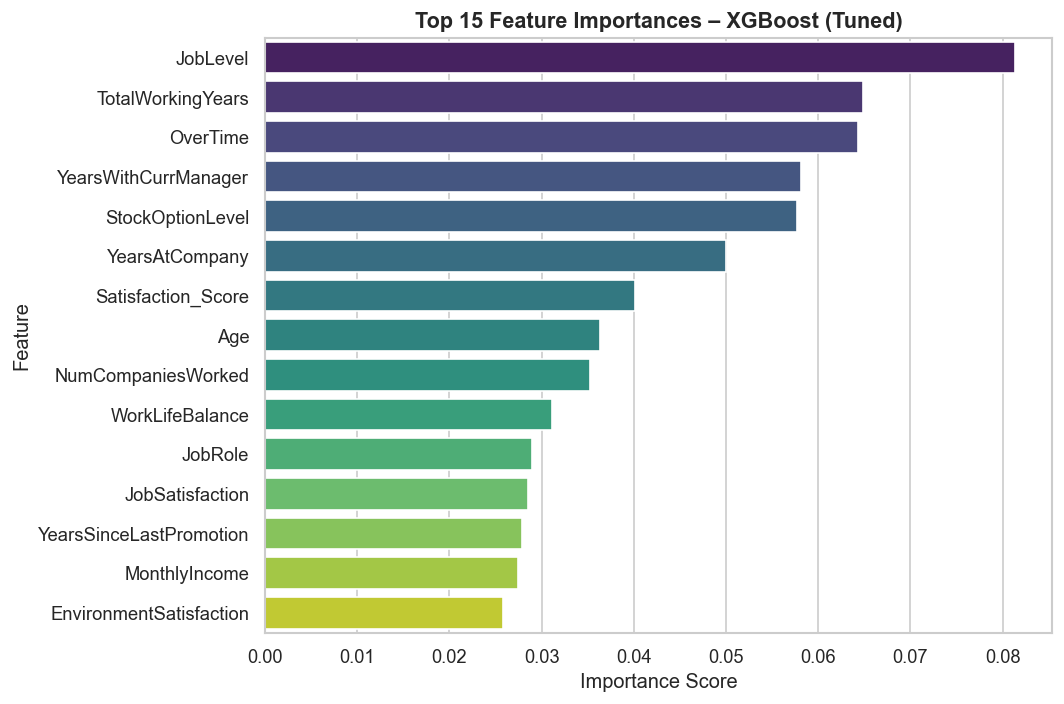


  These are the features that XGBoost relies on most when making predictions.
   OverTime, MonthlyIncome, and Age typically rank high in this dataset.


In [104]:
# ── Feature Importance (XGBoost Tuned) ───────────────────────────────────────
importances = best_xgb.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_imp_df, y='Feature', x='Importance',
            palette='viridis', orient='h')
plt.title('Top 15 Feature Importances – XGBoost (Tuned)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

print('\n  These are the features that XGBoost relies on most when making predictions.')
print('   OverTime, MonthlyIncome, and Age typically rank high in this dataset.')

===  Model Comparison Leaderboard ===
                 Model  Accuracy  Precision  Recall  F1-Score
1        Random Forest     84.35      57.14    8.51     14.81
2              XGBoost     83.67      48.57   36.17     41.46
3        Decision Tree     76.53      35.53   57.45     43.90
4  Logistic Regression     74.49      35.71   74.47     48.28


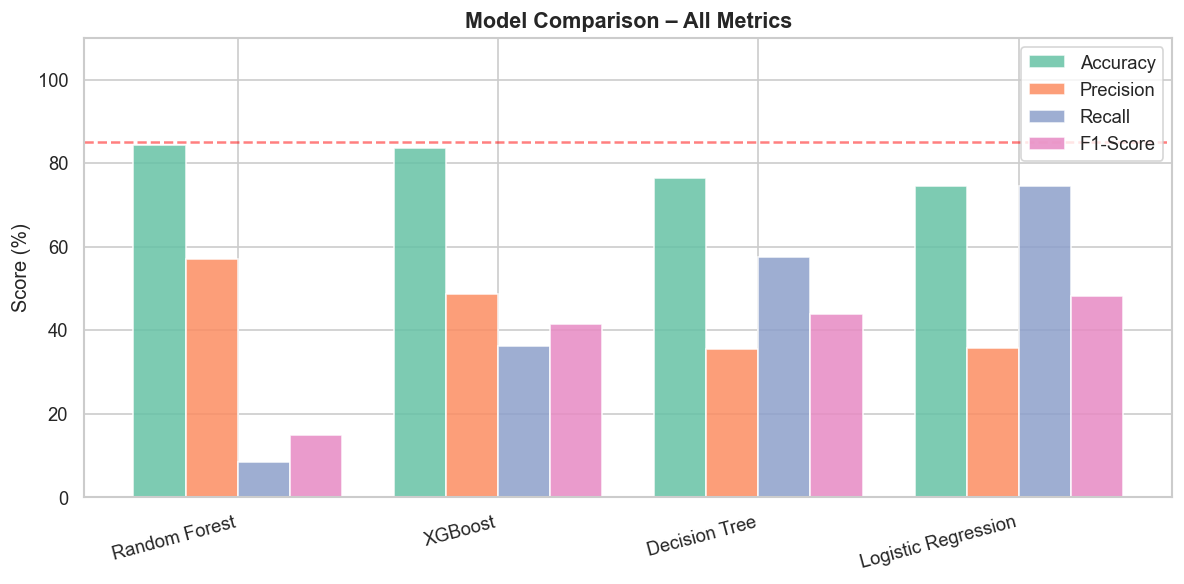

In [105]:
#model comparision table 
#Build comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model'    : name,
        'Accuracy' : res['Accuracy'],
        'Precision': res['Precision'],
        'Recall'   : res['Recall'],
        'F1-Score' : res['F1-Score']
    }
    for name, res in results.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

comparison_df.index += 1  # Rank starts at 1

print('===  Model Comparison Leaderboard ===')
print(comparison_df.to_string())

# ── Visual bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    bars = ax.bar(x + i * width, comparison_df[metric], width,
                  label=metric, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 110)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison – All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(y=85, color='red', linestyle='--', alpha=0.5, label='Target 85%')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

In [106]:
# Attrition Probability Prediction
#Using predict_proba to get attrition probability
# predict_proba returns [prob_stayed, prob_left] for each employee.
# We take column index 1 → probability of leaving.

proba_values = best_xgb.predict_proba(X_test)[:, 1]

# Build a result table for the first 15 test employees
prediction_df = X_test.head(15).copy()
prediction_df['Actual_Attrition']      = y_test.head(15).values
prediction_df['Predicted_Attrition']   = y_pred_xgb_tuned[:15]
prediction_df['Attrition_Probability'] = (proba_values[:15] * 100).round(1)

display_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                'Actual_Attrition', 'Predicted_Attrition', 'Attrition_Probability']

print('=== Attrition Probability for First 15 Test Employees ===')
print(prediction_df[display_cols].to_string())

# ── Risk Category ─────────────────────────────────────────────────────────────
def risk_category(prob):
    if prob >= 70: return '🔴 HIGH'
    elif prob >= 40: return '🟡 MEDIUM'
    else: return '🟢 LOW'

prediction_df['Risk_Level'] = prediction_df['Attrition_Probability'].apply(risk_category)

print('\n=== Risk Level Summary ===')
print(prediction_df['Risk_Level'].value_counts())

=== Attrition Probability for First 15 Test Employees ===
      Age  MonthlyIncome  YearsAtCompany  Actual_Attrition  Predicted_Attrition  Attrition_Probability
1061   24           2033               1                 0                    1              61.299999
891    44           2011              10                 0                    0               3.100000
456    31          11557               5                 0                    0              12.600000
922    44          19190              25                 0                    0               0.600000
69     36           3388               1                 1                    0              30.400000
1164   40           7945               4                 0                    0              15.800000
406    52           7969               5                 0                    0              20.000000
1330   43          19392              16                 0                    0               3.700000
1232   35      

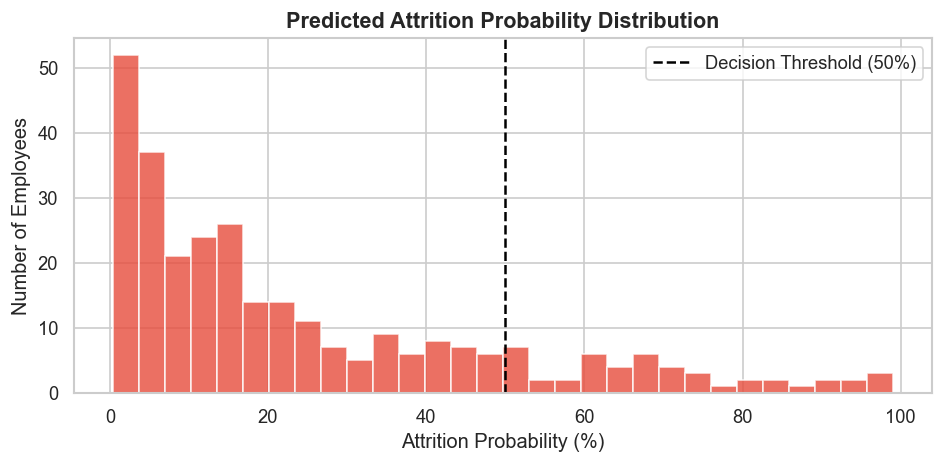

In [62]:
#Visualise probability distribution 
plt.figure(figsize=(8, 4))
plt.hist(proba_values * 100, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
plt.axvline(50, color='black', linestyle='--', label='Decision Threshold (50%)')
plt.xlabel('Attrition Probability (%)')
plt.ylabel('Number of Employees')
plt.title('Predicted Attrition Probability Distribution', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot_probability_distribution.png', bbox_inches='tight')
plt.show()

In [63]:
#LEADERBOARD INTEGRATION 
# ── Save model scores to a CSV leaderboard ────────────────────────────────────
# This mimics a Kaggle-style leaderboard for tracking experiments.

os.makedirs('leaderboard', exist_ok=True)   # create folder if it doesn't exist
scores_path = 'leaderboard/scores.csv'

# Write header + one row per model
with open(scores_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Model Name', 'Accuracy (%)', 'F1-Score (%)'])
    for name, res in results.items():
        writer.writerow([name, res['Accuracy'], res['F1-Score']])

print(f'✅ Leaderboard saved to: {scores_path}')
print()
print(pd.read_csv(scores_path).to_string(index=False))

✅ Leaderboard saved to: leaderboard/scores.csv

         Model Name  Accuracy (%)  F1-Score (%)
Logistic Regression         74.49         48.28
      Decision Tree         76.53         43.90
      Random Forest         84.35         14.81
            XGBoost         83.67         41.46
    XGBoost (Tuned)         82.31         44.68


---
## 🔐 Step 12 – Encryption Feature

> We use **Fernet symmetric encryption** from the `cryptography` library.  
> Fernet uses AES-128-CBC + HMAC-SHA256 under the hood — secure and easy to use.


In [64]:
# ── Generate a secret encryption key ─────────────────────────────────────────
# This key is required to both encrypt AND decrypt the file.
# IMPORTANT: In a real project, save this key securely (e.g., environment variable)!

key = Fernet.generate_key()           # generates a random 32-byte key
cipher = Fernet(key)

# Save key to file (for demo purposes only)
with open('leaderboard/secret.key', 'wb') as kf:
    kf.write(key)

print('✅ Encryption key generated and saved to: leaderboard/secret.key')
print(f'   Key (base64): {key.decode()[:30]}...')

✅ Encryption key generated and saved to: leaderboard/secret.key
   Key (base64): RHssuI0S2Qz-yDExedi9-F8HYkoi2W...


In [65]:
# ── Encrypt Function ──────────────────────────────────────────────────────────
def encrypt_file(input_path: str, output_path: str, fernet_cipher: Fernet) -> None:
    """
    Reads a file, encrypts its contents, and saves the encrypted version.

    Parameters:
        input_path    : Path to the original file (e.g., scores.csv)
        output_path   : Path where encrypted file will be saved (e.g., scores.enc)
        fernet_cipher : An initialised Fernet cipher object
    """
    with open(input_path, 'rb') as f:
        original_data = f.read()

    encrypted_data = fernet_cipher.encrypt(original_data)

    with open(output_path, 'wb') as f:
        f.write(encrypted_data)

    print(f'🔒 File encrypted: {input_path} → {output_path}')


# ── Decrypt Function ──────────────────────────────────────────────────────────
def decrypt_file(encrypted_path: str, output_path: str, fernet_cipher: Fernet) -> None:
    """
    Reads an encrypted file, decrypts it, and saves the original content.

    Parameters:
        encrypted_path : Path to the encrypted file (e.g., scores.enc)
        output_path    : Path where decrypted file will be saved
        fernet_cipher  : An initialised Fernet cipher object (same key used for encryption!)
    """
    with open(encrypted_path, 'rb') as f:
        encrypted_data = f.read()

    decrypted_data = fernet_cipher.decrypt(encrypted_data)

    with open(output_path, 'wb') as f:
        f.write(decrypted_data)

    print(f'🔓 File decrypted: {encrypted_path} → {output_path}')


print('✅ Encrypt and Decrypt functions defined!')

✅ Encrypt and Decrypt functions defined!


In [66]:
# ── Encrypt the leaderboard ───────────────────────────────────────────────────
encrypt_file(
    input_path    = 'leaderboard/scores.csv',
    output_path   = 'leaderboard/scores.enc',
    fernet_cipher = cipher
)

# Verify: show raw bytes of encrypted file (unreadable without key)
with open('leaderboard/scores.enc', 'rb') as f:
    enc_preview = f.read()[:80]
print(f'\n🔍 Encrypted file preview (first 80 bytes): {enc_preview}')

🔒 File encrypted: leaderboard/scores.csv → leaderboard/scores.enc

🔍 Encrypted file preview (first 80 bytes): b'gAAAAABp374oVMEZSTXkxrMreSZcEEsYh7oEyqAN9XmBpynVj62-9ka3bQSBPxJLqRIvq7oKKeTIgaga'


In [67]:
# ── Decrypt and verify ────────────────────────────────────────────────────────
decrypt_file(
    encrypted_path = 'leaderboard/scores.enc',
    output_path    = 'leaderboard/scores_decrypted.csv',
    fernet_cipher  = cipher
)

# Confirm the decrypted file matches the original
print('\n=== Decrypted Leaderboard (should match original) ===')
print(pd.read_csv('leaderboard/scores_decrypted.csv').to_string(index=False))

🔓 File decrypted: leaderboard/scores.enc → leaderboard/scores_decrypted.csv

=== Decrypted Leaderboard (should match original) ===
         Model Name  Accuracy (%)  F1-Score (%)
Logistic Regression         74.49         48.28
      Decision Tree         76.53         43.90
      Random Forest         84.35         14.81
            XGBoost         83.67         41.46
    XGBoost (Tuned)         82.31         44.68


---
## ✅ Step 13 – Final Summary

In [68]:
# ── Print final project summary ───────────────────────────────────────────────
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy   = comparison_df.iloc[0]['Accuracy']
best_f1         = comparison_df.iloc[0]['F1-Score']

print('='*60)
print('   🏆  AttritionX – Project Summary  🏆')
print('='*60)
print(f'  Dataset      : IBM HR Analytics (1470 employees, 35 features)')
print(f'  Attrition %  : {df["Attrition"].mean()*100:.1f}% left the company')
print(f'  Best Model   : {best_model_name}')
print(f'  Accuracy     : {best_accuracy}%')
print(f'  F1-Score     : {best_f1}%')
print()
print('  New Features Created:')
print('  • Income_per_Age          – earning efficiency relative to age')
print('  • Years_at_Company_Ratio  – loyalty ratio')
print('  • Satisfaction_Score      – composite satisfaction index')
print()
print('  Outputs Generated:')
print('  • leaderboard/scores.csv         – model scores')
print('  • leaderboard/scores.enc         – encrypted leaderboard')
print('  • leaderboard/scores_decrypted.csv – verified decryption')
print('  • 7 visualisation plots saved as PNG')
print('='*60)

   🏆  AttritionX – Project Summary  🏆
  Dataset      : IBM HR Analytics (1470 employees, 35 features)
  Attrition %  : 16.1% left the company
  Best Model   : Random Forest
  Accuracy     : 84.35%
  F1-Score     : 14.81%

  New Features Created:
  • Income_per_Age          – earning efficiency relative to age
  • Years_at_Company_Ratio  – loyalty ratio
  • Satisfaction_Score      – composite satisfaction index

  Outputs Generated:
  • leaderboard/scores.csv         – model scores
  • leaderboard/scores.enc         – encrypted leaderboard
  • leaderboard/scores_decrypted.csv – verified decryption
  • 7 visualisation plots saved as PNG
